In [1]:
# import sys
# from pathlib import Path
# print(Path.cwd())
# print(Path.cwd().parents[1])
# sys.path.append(str(Path.cwd().parents[1]))
from modeling.CustomDataset import * # .modeling
from modeling.model import *
from modeling.ModelTraining import *
from modeling.utils import *
# from torch.utils.data import WeightedRandomSampler
# from sklearn.model_selection import train_test_split
# from torchinfo import summary

/Users/augustmilliken/opt/anaconda3/envs/pya13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/augustmilliken/opt/anaconda3/envs/pya13/lib/python3.13/site-packages/google/cloud/bigquery/__init__.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


Optuna


torch.amp.autocast
torch gradscaler 

fuse

can use google cloud credits, ask everly if needed

In [ ]:
seed=42
prep(seed) #device = 'gpu'
data = make_dataset(
    start_date="2017-01-01" , 
    label_col="events"#, 
    #seed=seed
)
print('Loaded')
in_dim = data.__getitem__(1)[0].shape[0] # may need to be 1
out_dim = 384 # rename
# check 8 better when streamlined
batch_size = 128#8, 16, 32, 64, 128
num_classes = data.get_num_classes() + 1
print('Making dataloaders')
train_loader, dev_loader, test_loader = make_loaders(
    data=data, 
    seed=seed,
    batch_size=batch_size
)
print('Made')

Loading 2017-01-01 dataset...
Loaded
Making dataloaders
Made


## class weights

try ploting weight vs count: should not be exponential\
max(weight) / min(weight) ≲ 10–20   (at least at first)

Quick checks:
- Track loss per class
- Track accuracy per class
- Track mean logit per class

If you see:
- Loss decreasing only for 1–2 classes
- Other classes’ logits stuck near zero
- That means the model never escapes its early bias

Inspect prediction entropy during training\
This tells you when collapse happens.\
Compute:

entropy = -sum(p * log(p))


If entropy collapses early → optimization issue\
If entropy collapses late → overfitting / data leakage\
If entropy never rises → learning rate too low or weights too extreme

In [3]:
num_heads = 1 # 2 
ff_dim = 4 * 32 # dim_inner # int((in_dim * (2/3)) + out_dim)
convert_drop = 0.3 # 0.5 for non-cosine 
convert_trans_drop = 0.1
sub_convert = Convertion(
    dim_in=in_dim, 
    dim_out=out_dim, 
    num_heads=num_heads, 
    ff_dim=ff_dim, 
    drop=convert_drop, 
    trans_drop=convert_trans_drop,
    # dim_inner = 32,
    num_layers=4
)
convert_lr = 1e-2 
convert_decay = 1e-4
convert_optim = optim.AdamW(params=sub_convert.parameters(), lr=convert_lr, weight_decay=convert_decay) # may want to add weight decay
convert_loss_fn = nn.CosineEmbeddingLoss() 
# convert_loss_fn._get_name
# convert_loss_fn = nn.MSELoss()
sub_convert = torch.compile(sub_convert, mode="reduce-overhead")
convert_mod = ModelTraining(
    model=sub_convert, 
    batch_size=batch_size,
    num_classes=num_classes,
    mod_to_train=4
)
sub_convert = convert_mod.fit(
    # sub_convert, 
    opt=convert_optim, 
    loss_fn=convert_loss_fn, 
    train_data=train_loader, 
    val_data=dev_loader,  
    epochs=5
    # mod_to_train=4
    )

/Users/augustmilliken/opt/anaconda3/envs/pya13/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []

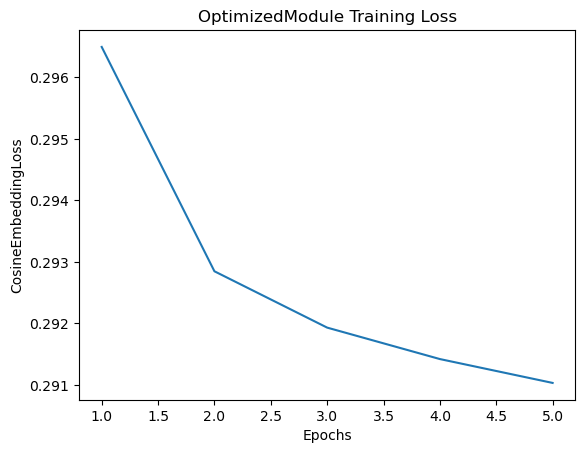

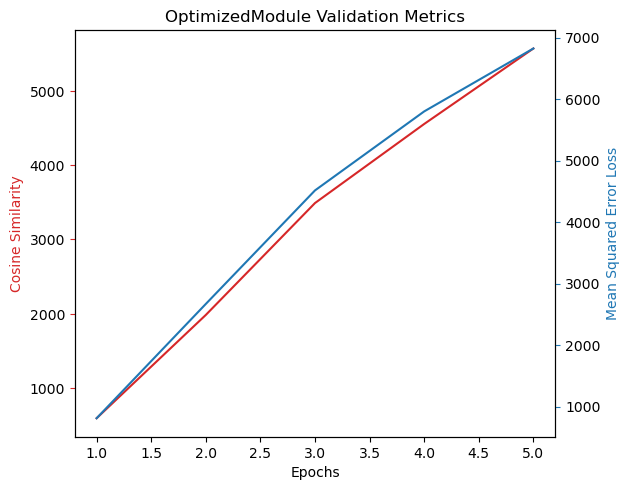

In [ ]:
convert_mod.plot_loss()
convert_mod.plot_metrics()

In [5]:
convert_mod.metric

[[tensor(711.9614),
  tensor(2767.4597),
  tensor(4800.0020),
  tensor(6279.1694),
  tensor(7759.5508)],
 [tensor(879.8953),
  tensor(3314.1262),
  tensor(5874.0581),
  tensor(7867.8423),
  tensor(9849.5312)]]

In [ ]:
for name, param in convert_mod.model.named_parameters():
    print(name)
    print(param)

pos_embed
Parameter containing:
tensor([[[ 1.7831, -0.0750,  1.1276,  ...,  0.2103, -0.2275,  0.3465],
         [-1.0419,  1.3694,  0.7826,  ..., -0.6434,  0.3828,  1.3010],
         [ 0.2483, -0.4466,  0.8113,  ...,  2.1023, -1.0024, -1.6749],
         ...,
         [-0.0042, -0.0948,  2.2673,  ...,  3.1400, -0.5464,  0.1108],
         [ 0.8950,  0.2782,  1.4513,  ...,  0.3435, -1.0517, -0.1772],
         [-1.3308,  0.3401, -1.4156,  ..., -0.5737, -0.8924, -2.1831]]],
       requires_grad=True)
embed.weight
Parameter containing:
tensor([[ 0.3275],
        [-0.7662],
        [-0.8372],
        [-0.9447],
        [-0.1883],
        [-0.1917],
        [-0.0200],
        [-0.4253],
        [ 0.1333],
        [-0.1788],
        [ 0.9682],
        [ 0.8960],
        [ 0.1657],
        [ 0.6853],
        [ 0.5522],
        [ 0.7305],
        [ 0.0074],
        [-0.7021],
        [-0.0156],
        [-0.9949],
        [ 0.2153],
        [-0.6548],
        [-0.3570],
        [ 0.0962],
        

In [4]:
# NOTE: using if concatenating
sub_in = (out_dim) # + in_dim
sub_drop = 0.3
sub_class = Classification(out_dim, num_classes, sub_drop)
class_lr = 1e-3 
class_decay = 1e-4
class_optim = optimizer = optim.AdamW(params = sub_class.parameters(), lr=class_lr, weight_decay=class_decay) 
class_loss_fn = nn.CrossEntropyLoss(weight = calc_loss_weights(data=data, alpha=0.999999)) 
class_mod = ModelTraining(
    sub_class, 
    num_classes=num_classes,
    batch_size=batch_size,
    mod_to_train=2
    )
sub_class = class_mod.fit(
    # model=sub_class, 
    opt=class_optim, 
    loss_fn=class_loss_fn, 
    train_data=train_loader, 
    val_data=dev_loader, 
    epochs=5 
    
    # batch_size=batch_size
    )

Layer (type:depth-idx)                   Output Shape              Param #
Classification                           [128, 11]                 71,556
├─Linear: 1-1                            [128, 267]                102,795
├─LeakyReLU: 1-2                         [128, 267]                --
├─Dropout: 1-3                           [128, 267]                --
├─Linear: 1-4                            [128, 11]                 2,948
Total params: 177,299
Trainable params: 177,299
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 13.54
Input size (MB): 0.20
Forward/backward pass size (MB): 0.28
Params size (MB): 0.42
Estimated Total Size (MB): 0.90



Fitting Classification model...


Epochs: 100%|██████████| 5/5 [03:28<00:00, 41.67s/it]


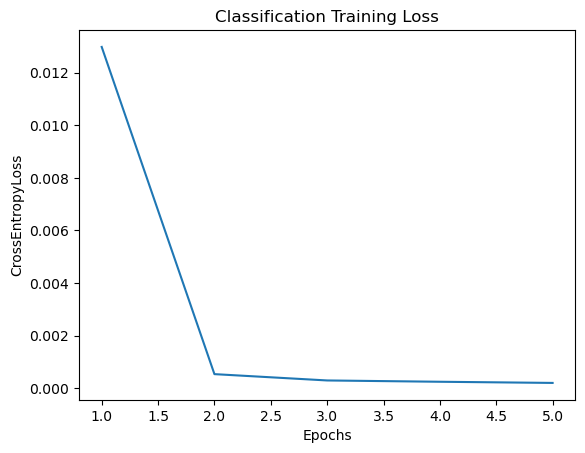

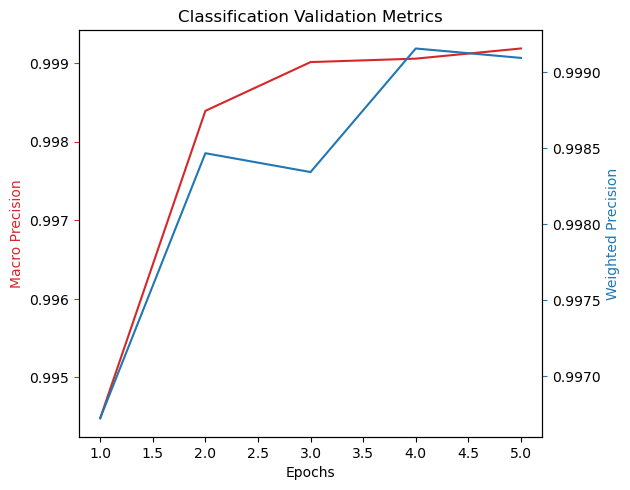

In [5]:
class_mod.plot_loss()
class_mod.plot_metrics()

In [21]:
# num_heads = 2 
# ff_dim = int((in_dim * (2/3)) + out_dim)
# convert_drop = 0 # 0.5 for non-cosine 
# simple_sub_convert = Convertion(in_dim, out_dim, num_heads, ff_dim, convert_drop)
# sub_convert = Convertion(in_dim, out_dim, num_heads, ff_dim, convert_drop)
# sub_convert = sub_convert.load_state_dict(torch.load('best_models/best_Convertion_model.pt'))
# sub_convert.dim_in = in_dims

sub_in = (out_dim) # + in_dim
sub_drop = 0.3
simple_sub_class = Classification(out_dim, num_classes, sub_drop)

drop = 0.5
model = Multi(sub_convert, simple_sub_class, drop, concat=False, freeze=True) #in_dim, sub_class, False
print(summary(model, input_size=(batch_size, in_dim)))

lr = 1e-2
class_decay = 1e-2

optimizer = optim.AdamW(params = model.parameters(), lr=lr, weight_decay=class_decay) 
# NOTE: need to fix weights
loss_fn = nn.CrossEntropyLoss(weight = calc_loss_weights(data=data, alpha=0.999999), reduction='mean')#weight = calc_loss_weights(data=data, alpha=0.999999)
multi_mod = ModelTraining(
    model, 
    num_classes=num_classes, 
    batch_size=batch_size
    )
model = multi_mod.fit(
    # model, 
    optimizer, 
    loss_fn, 
    train_loader, 
    dev_loader, 
    epochs=5
    )

Layer (type:depth-idx)                                  Output Shape              Param #
Multi                                                   [128, 11]                 --
├─Convertion: 1-1                                       [128, 384]                928,564
│    └─Sequential: 2-1                                  [128, 384]                --
│    │    └─Dropout: 3-1                                [128, 78]                 --
│    │    └─Linear: 3-2                                 [128, 384]                (30,336)
│    │    └─LeakyReLU: 3-3                              [128, 384]                --
│    │    └─TransformerEncoder: 3-4                     [128, 384]                (928,564)
├─Classification: 1-2                                   [128, 11]                 71,556
│    └─Sequential: 2-2                                  [128, 11]                 --
│    │    └─Linear: 3-5                                 [128, 267]                102,795
│    │    └─LeakyReLU: 3-6       

Epochs: 100%|██████████| 5/5 [04:19<00:00, 51.98s/it]


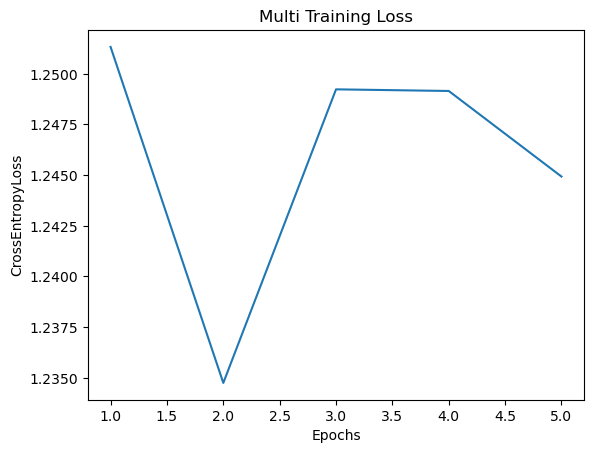

In [22]:
multi_mod.plot_loss()

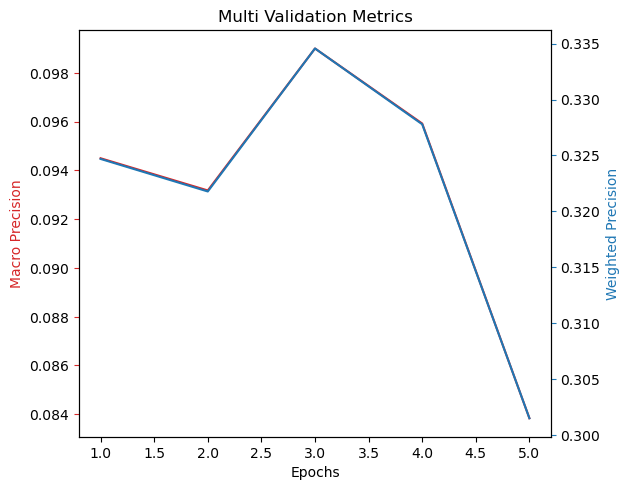

In [23]:
multi_mod.plot_metrics()

In [25]:
multi_mod.check_preds(dev_data)

tensor([     0,      0,      0,      0,      0,   4214, 124525])


In [3]:
# classification for just game state
game_drop = 0.3
# print(in_dim)
game_class = Classification(in_dim, num_classes, game_drop, num_hidden=3) 
game_lr = 1e-1
game_decay = 1e-4
game_optim = optimizer = optim.AdamW(params = game_class.parameters(), lr=game_lr, weight_decay=game_decay) 
game_loss_fn = nn.CrossEntropyLoss(weight = calc_loss_weights(data=data, alpha=0.999999), reduction='mean') # , label_smoothing=0.05 
game_mod = ModelTraining(
    game_class,
    num_classes=num_classes,
    batch_size=batch_size,
    mod_to_train=0
    )
game_class = game_mod.fit(
    # model=game_class, 
    opt=game_optim, 
    loss_fn=game_loss_fn, 
    train_data=train_loader, 
    val_data=dev_loader, 
    # num_classes=num_classes,
    epochs=5
    # mod_to_train=0,
    # batch_size=batch_size
    )

Layer (type:depth-idx)                   Output Shape              Param #
Classification                           [128, 11]                 --
├─Linear: 1-1                            [128, 63]                 4,977
├─LeakyReLU: 1-2                         [128, 63]                 --
├─Dropout: 1-3                           [128, 63]                 --
├─Linear: 1-4                            [128, 63]                 4,032
├─LeakyReLU: 1-5                         [128, 63]                 --
├─Dropout: 1-6                           [128, 63]                 --
├─Linear: 1-7                            [128, 63]                 (recursive)
├─LeakyReLU: 1-8                         [128, 63]                 --
├─Dropout: 1-9                           [128, 63]                 --
├─Linear: 1-10                           [128, 63]                 (recursive)
├─LeakyReLU: 1-11                        [128, 63]                 --
├─Dropout: 1-12                          [128, 63]           

Epochs: 100%|██████████| 5/5 [04:39<00:00, 55.91s/it]


In [4]:
game_mod.best_metric

[tensor(0.1616), tensor(0.4736)]

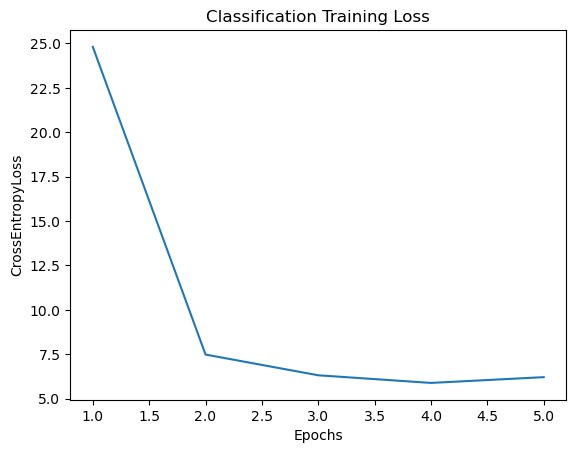

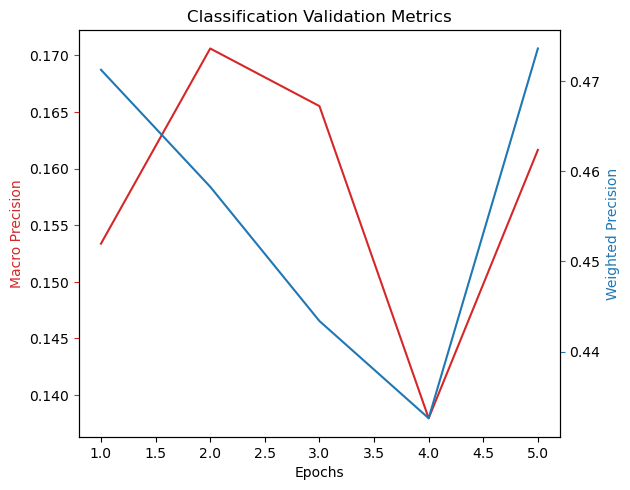

In [5]:
game_mod.plot_loss()
game_mod.plot_metrics()

In [6]:
game_mod.check_preds(dev_loader)

RuntimeError: stack expects each tensor to be equal size, but got [128, 78] at entry 0 and [99, 78] at entry 1005

In [ ]:
for name, param in sub_class.named_parameters():
    if param.grad is not None:
        print(name, param.grad)

layer1.weight tensor([[-2.7922e-15,  1.4487e-14, -1.2853e-14,  ...,  5.7784e-16,
         -2.4516e-16,  7.9309e-17],
        [ 1.5905e-14, -8.3243e-14,  7.3780e-14,  ..., -3.3041e-15,
          1.4033e-15, -3.1720e-16],
        [-6.2580e-15,  3.2741e-14, -2.9063e-14,  ...,  1.1973e-15,
         -5.5070e-16,  1.7358e-17],
        ...,
        [ 1.6357e-14, -8.6244e-14,  7.6267e-14,  ..., -3.4343e-15,
          1.4485e-15, -2.6317e-16],
        [-1.1202e-14,  5.9307e-14, -5.2421e-14,  ...,  2.3582e-15,
         -9.9478e-16,  1.5349e-16],
        [ 1.2498e-14, -6.5725e-14,  5.8179e-14,  ..., -2.6040e-15,
          1.1055e-15, -1.9692e-16]])
layer1.bias tensor([ 2.5920e-13, -1.4848e-12,  5.8289e-13,  1.5506e-12, -1.2070e-12,
         7.0460e-13, -1.1715e-12,  1.8666e-12,  1.3233e-12, -7.5154e-14,
        -1.7521e-13, -2.4629e-13,  1.4513e-12, -2.9400e-12, -1.2955e-12,
         2.7306e-12, -2.2120e-12,  1.2917e-12,  6.0920e-13, -3.1765e-13,
        -3.5031e-13,  1.7040e-14, -7.8817e-13, -1.

In [35]:
for name, param in game_class.named_parameters():
    if param.grad is not None:
        print(name, param.grad)

layer1.weight tensor([[-5.8943e-04, -1.0057e-04, -3.9637e-03,  ..., -7.9087e-11,
         -2.4548e-10, -3.7554e-10],
        [ 9.1717e-04,  7.8870e-03,  2.2476e-01,  ..., -1.3202e-09,
          5.0367e-10,  2.5403e-09],
        [-2.0398e-03, -5.5440e-04, -1.9219e-02,  ..., -5.4225e-10,
         -1.8218e-10, -6.7129e-11],
        ...,
        [-1.4739e-03, -5.0419e-04, -1.6317e-02,  ..., -2.5664e-10,
         -4.3806e-12, -2.8237e-10],
        [-7.6147e-04, -4.9265e-04, -1.4757e-02,  ...,  2.0570e-11,
         -9.6082e-11, -2.3648e-10],
        [-1.2474e-03,  6.7144e-04,  2.1456e-02,  ...,  2.0479e-10,
         -8.3933e-11, -8.2889e-10]])
layer1.bias tensor([-1.9644e-10,  1.1110e-08, -9.5167e-10,  6.6760e-10, -2.4003e-09,
        -1.4472e-08, -2.8609e-09,  9.8137e-10, -5.9972e-13, -3.2716e-09,
        -7.0133e-10, -1.9297e-10, -1.5230e-09, -1.7504e-09, -1.0035e-09,
        -2.0615e-11, -2.7550e-09, -6.1533e-09,  1.8871e-09, -1.3701e-08,
        -2.7234e-08, -3.9416e-09, -3.1549e-09, -1.

In [ ]:
game_class.eval()
with torch.no_grad():
    output = game_class(torch.stack([feat for feat, label, sent in dev_data])) 
print(output)
print(torch.argmax(output, dim=1))
# print([label for feat, label, sent in dev_data])

tensor([[3526935.7500, 4313994.5000, 6291586.0000,  ..., 6343544.0000,
         6480026.0000, 4768049.0000],
        [5559037.0000, 6212610.0000, 8494916.0000,  ..., 8582723.0000,
         8781083.0000, 7257211.0000],
        [5448934.5000, 6104831.0000, 8356385.5000,  ..., 8451582.0000,
         8644749.0000, 7117963.0000],
        ...,
        [4957366.0000, 5628068.5000, 7747860.0000,  ..., 7868962.0000,
         8031916.5000, 6510331.0000],
        [5324659.5000, 5983261.5000, 8200435.0000,  ..., 8305979.0000,
         8493931.0000, 6958851.0000],
        [6027113.0000, 6673699.5000, 9094114.0000,  ..., 9150249.0000,
         9369810.0000, 7854839.5000]])
tensor([6, 6, 6,  ..., 6, 6, 6])


KeyboardInterrupt: 

In [ ]:
convert_mod.learned_params()



0 other
1 single 
2 double 
3 triple 
4 homerun 
5 strikeout
6 out 
7 multi out
8 walk 
9 awarded first 
10 field 



3 double 
12 hr
18 single
(19) strike out
21 tripple 

out: 6, 8, 9, 14, 16

double play (mult out): 4, 10, 15, 17, 20, 22

walk: 13, 24

awarded first: 2, 11

other: 2, 23 (5)

field thing: 5, 7 


no strike out or walks??

In [ ]:
def check_preds(self, num_classes, dataloader, mod_to_train): 
    macro_precision = Precision(task="multiclass", average="macro", num_classes=num_classes)
    weighted_precision = Precision(task="multiclass", average="weighted", num_classes=num_classes)
    result = self.validation(
        dataloader,
        macro_precision,
        weighted_precision,
        mod_to_train=mod_to_train
    )

In [ ]:
def check_preds(model:ModelTraining, num_classes, dataloader, mod_to_train): 
    macro_precision = Precision(task="multiclass", average="macro", num_classes=num_classes)
    weighted_precision = Precision(task="multiclass", average="weighted", num_classes=num_classes)
    result = model.validation(
        dataloader,
        macro_precision,
        weighted_precision,
        mod_to_train=mod_to_train
    )

In [38]:
macro_precision = Precision(task="multiclass", average="macro", num_classes=num_classes)
weighted_precision = Precision(task="multiclass", average="weighted", num_classes=num_classes)

In [ ]:
convert_result = validation(sub_convert,
           test_loader,
           macro_precision,
           weighted_precision, 
           1)
print(convert_result[0])

In [ ]:
class_result = validation(sub_class,
           test_loader,
           macro_precision,
           weighted_precision, 
           2)
print(class_result)
macro_precision.reset()
weighted_precision.reset() 

In [ ]:
model_result = validation(model,
           test_loader,
           macro_precision,
           weighted_precision, 
           0)
print(model_result)
macro_precision.reset()
weighted_precision.reset() 

In [ ]:

game_result = game_mod.validation(
    # game_class,
    test_loader,
    macro_precision,
    weighted_precision,
    # torch
    mod=0
    )
print(game_result)
macro_precision.reset()
weighted_precision.reset() 

TypeError: ModelTraining.validation() missing 1 required positional argument: 'MSE'